In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [ ]:

IMG_SIZE = 224
BATCH_SIZE = 32   
EPOCHS = 30       
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
(ds_train, ds_test), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train[:80%]", "train[80%:]"], 
    as_supervised=True,
    with_info=True
)

In [4]:

NUM_CLASSES = ds_info.features["label"].num_classes
print("Number of classes:", NUM_CLASSES)

Number of classes: 37


In [5]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [6]:
def preprocess_train(img, label):
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = data_augmentation(img)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def preprocess_val(img, label):
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


train_ds = ds_train.map(preprocess_train, num_parallel_calls=AUTOTUNE).shuffle(512).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = ds_test.map(preprocess_val, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [7]:
def pw_dw_pw_block(x, out_channels, stride=1):
    # Pointwise
    x = tf.keras.layers.Conv2D(out_channels // 2, 1, use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    # Depthwise
    x = tf.keras.layers.DepthwiseConv2D(3, strides=stride, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    # Pointwise
    x = tf.keras.layers.Conv2D(out_channels, 1, use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    return x

In [8]:

class DynamicSeriesActivation(tf.keras.layers.Layer):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc1 = tf.keras.layers.Dense(channels // reduction, activation="relu")
        self.fc2 = tf.keras.layers.Dense(channels, activation="sigmoid")
    def call(self, x):
        gap = tf.reduce_mean(x, axis=[1, 2])
        scale = self.fc2(self.fc1(gap))
        scale = tf.reshape(scale, [-1,1,1,x.shape[-1]])
        return x * scale

In [ ]:
def VanillaNetPP():
    inputs = tf.keras.Input(shape=(224, 224, 3))

    # Stem
    x = tf.keras.layers.Conv2D(128, 4, strides=4, padding="same", use_bias=False)(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)   # 56x56

    # Stages
    x = pw_dw_pw_block(x, 256, stride=2)   # 28x28
    x = pw_dw_pw_block(x, 512, stride=2)   # 14x14
    x = pw_dw_pw_block(x, 1024, stride=2)  # 7x7

    # DSA
    x = DynamicSeriesActivation(1024)(x)

    # Head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)  
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs)

In [10]:
tf.keras.backend.clear_session()
model = VanillaNetPP()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 56, 56, 128)    │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 28, 28, 128)    │         1,152 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 256)    │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 14, 14, 256)    │         2,304 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,231,333 (4.70 MB)

 Trainable params: 1,223,909 (4.67 MB)

 Non-trainable params: 7,424 (29.00 KB)

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="top1"),
             tf.keras.metrics.SparseTopKCategoricalAccuracy(5, name="top5")]
)

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 53s 346ms/step - loss: 3.5621 - top1: 0.0544 - top5: 0.2156 - val_loss: 3.6580 - val_top1: 0.0190 - val_top5: 0.1318
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 70s 333ms/step - loss: 3.3330 - top1: 0.1099 - top5: 0.3589 - val_loss: 3.9109 - val_top1: 0.0190 - val_top5: 0.1345
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 36s 342ms/step - loss: 3.2180 - top1: 0.1234 - top5: 0.4180 - val_loss: 4.4633 - val_top1: 0.0190 - val_top5: 0.1345
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 35s 323ms/step - loss: 3.0508 - top1: 0.1615 - top5: 0.4870 - val_loss: 4.9760 - val_top1: 0.0340 - val_top5: 0.1345
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 332ms/step - loss: 2.9236 - top1: 0.1947 - top5: 0.5252 - val_loss: 5.1202 - val_top1: 0.0326 - val_top5: 0.1413
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 324ms/step - loss: 2.8616 - top1: 0.2193 - top5: 0.5628 - val_loss: 4.7667 - val_top1: 0.0421 - val_top5: 0.1617
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 36s 323ms/step - loss: 2.7200 - 

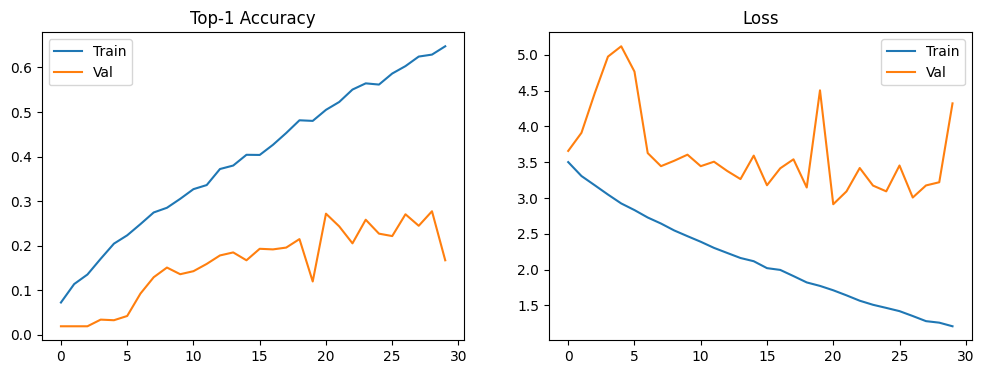

In [13]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["top1"], label="Train")
plt.plot(history.history["val_top1"], label="Val")
plt.title("Top-1 Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()
plt.show()

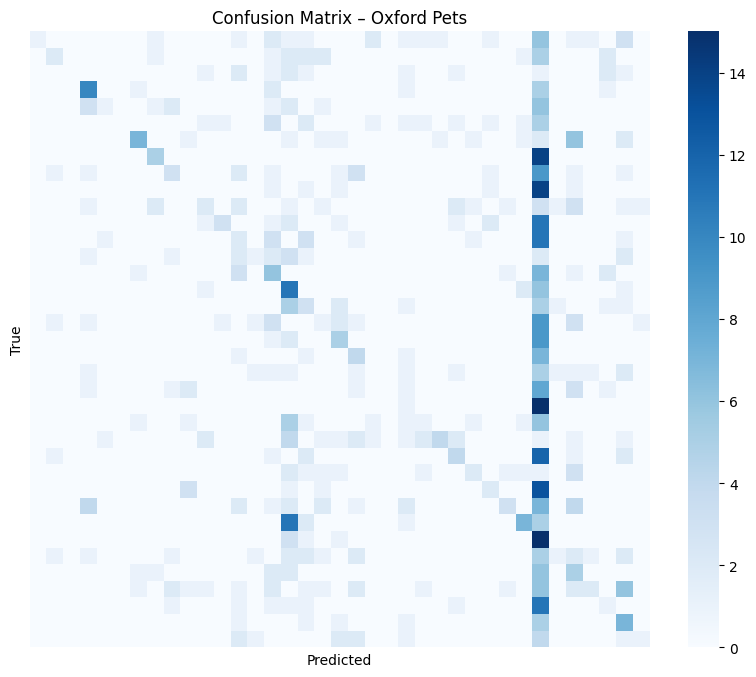

In [14]:
y_true, y_pred = [], []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix – Oxford Pets")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [15]:
top1 = history.history["val_top1"][-1] * 100
top5 = history.history["val_top5"][-1] * 100
print(f"Final Top-1: {top1:.2f}%")
print(f"Final Top-5: {top5:.2f}%")

Final Top-1: 16.71%
Final Top-5: 53.12%
